# ЛР1. Валидация данных, обучение и интерпретация MLP на MNIST

Ноутбук — сквозной проход по всем частям работы через вызовы пакета `mnist_validation`. Тяжёлые вычисления (полная сетка обучения, окклюзия по всем изображениям, сравнение фреймворков) выполняются командами `make validate grid interpret jax`; здесь мы делаем лёгкие живые вызовы и показываем готовые таблицы и рисунки из `reports/`.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from mnist_validation.config import load_config
from mnist_validation.data.loading import load_bundle_npz

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG = ROOT / 'reports' / 'figures'
TAB = ROOT / 'reports' / 'tables'
config = load_config(ROOT / 'configs' / 'lab1_base.yaml')
print('seed', config.seed, '| hidden', config.model.hidden_sizes)

seed 42 | hidden (256, 128)


## Часть 1. Анализ и валидация набора

Живой расчёт статистик классов и репрезентативности на обработанных данных, затем — готовые таблицы и рисунки.

In [2]:
from mnist_validation.data.statistics import class_distribution_frame, imbalance_ratio

test = load_bundle_npz(ROOT / 'data' / 'processed' / 'test.npz')
original = load_bundle_npz(ROOT / 'data' / 'processed' / 'original.npz')
print('коэффициент дисбаланса (обучающая часть):', round(imbalance_ratio(original.labels), 3))
display(class_distribution_frame(original.labels))

коэффициент дисбаланса (обучающая часть): 4.798


,class,count,proportion
0,0,5331,0.098722
1,1,6068,0.112370
2,2,5362,0.099296
3,3,8997,0.166611
4,4,5258,0.097370
5,5,4879,0.090352
6,6,5326,0.098630
7,7,5638,0.104407
8,8,5266,0.097519
9,9,1875,0.034722


In [3]:
display(pd.read_csv(TAB / 'part1_quality_summary.csv'))
display(pd.read_csv(TAB / 'part1_representativeness.csv'))

,reason,description,count
0,full_duplicate,Exact duplicate row (identical label and pixels),3866
1,same_label_duplicate,Duplicate image within the same class,3866
2,label_conflict,Identical image assigned conflicting labels,0
3,out_of_range,"Pixel value outside [0, 255]",0
4,near_empty,Near-empty image (too few active pixels),0
5,near_full,Near-completely-filled image (too many active ...,0
6,intensity_outlier,Outlier intensity/fill statistic within its class,462
7,centroid_outlier,Far from class centroid in pixel space,461
8,knn_outlier,kNN-distance outlier in PCA space,300
9,isolation_forest_outlier,Isolation Forest outlier in PCA space,600


,class,count,proportion,required_n,sufficient
0,0,5923,0.098717,136.717452,True
1,1,6742,0.112367,153.265087,True
2,2,5958,0.099300,137.436329,True
3,3,9997,0.166617,213.370997,True
4,4,5842,0.097367,135.049756,True
5,5,5421,0.090350,126.291643,True
6,6,5918,0.098633,136.614670,True
7,7,6265,0.104417,143.697086,True
8,8,5851,0.097517,135.235332,True
9,9,2083,0.034717,51.494988,True


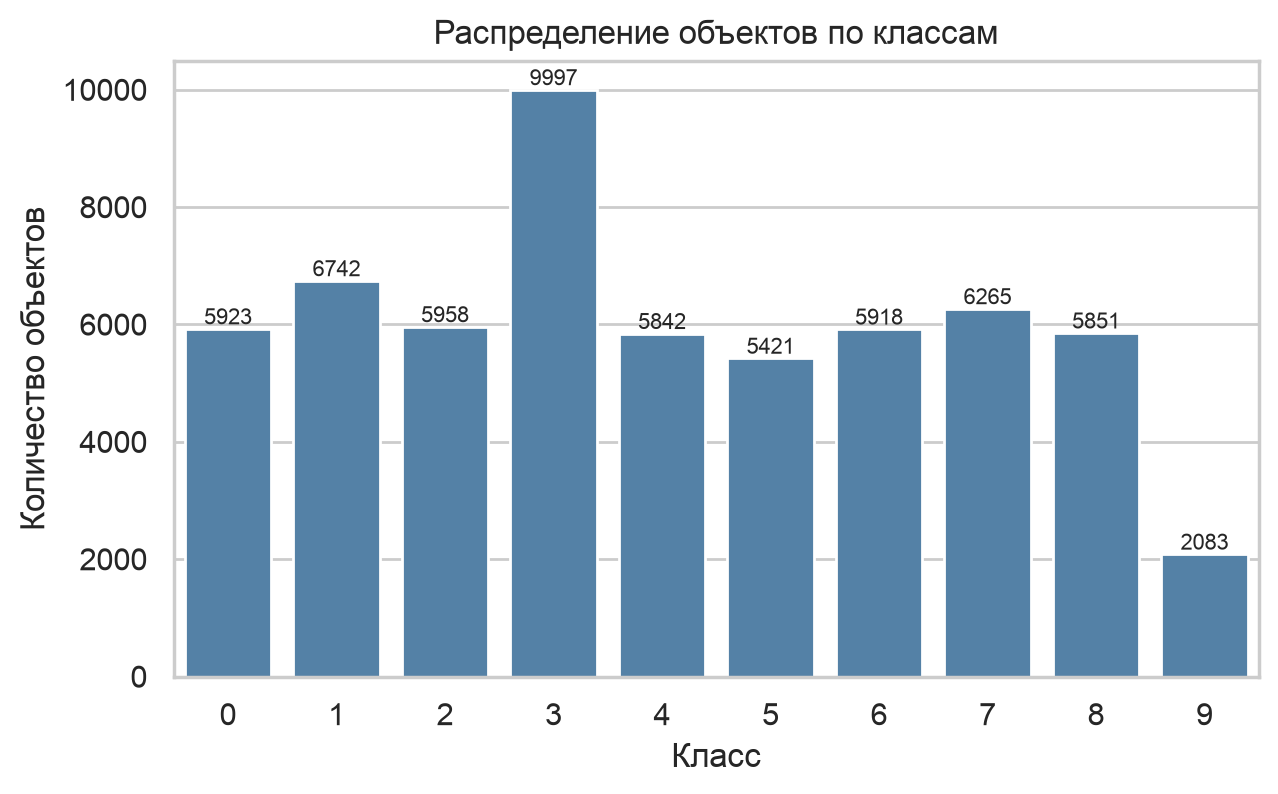

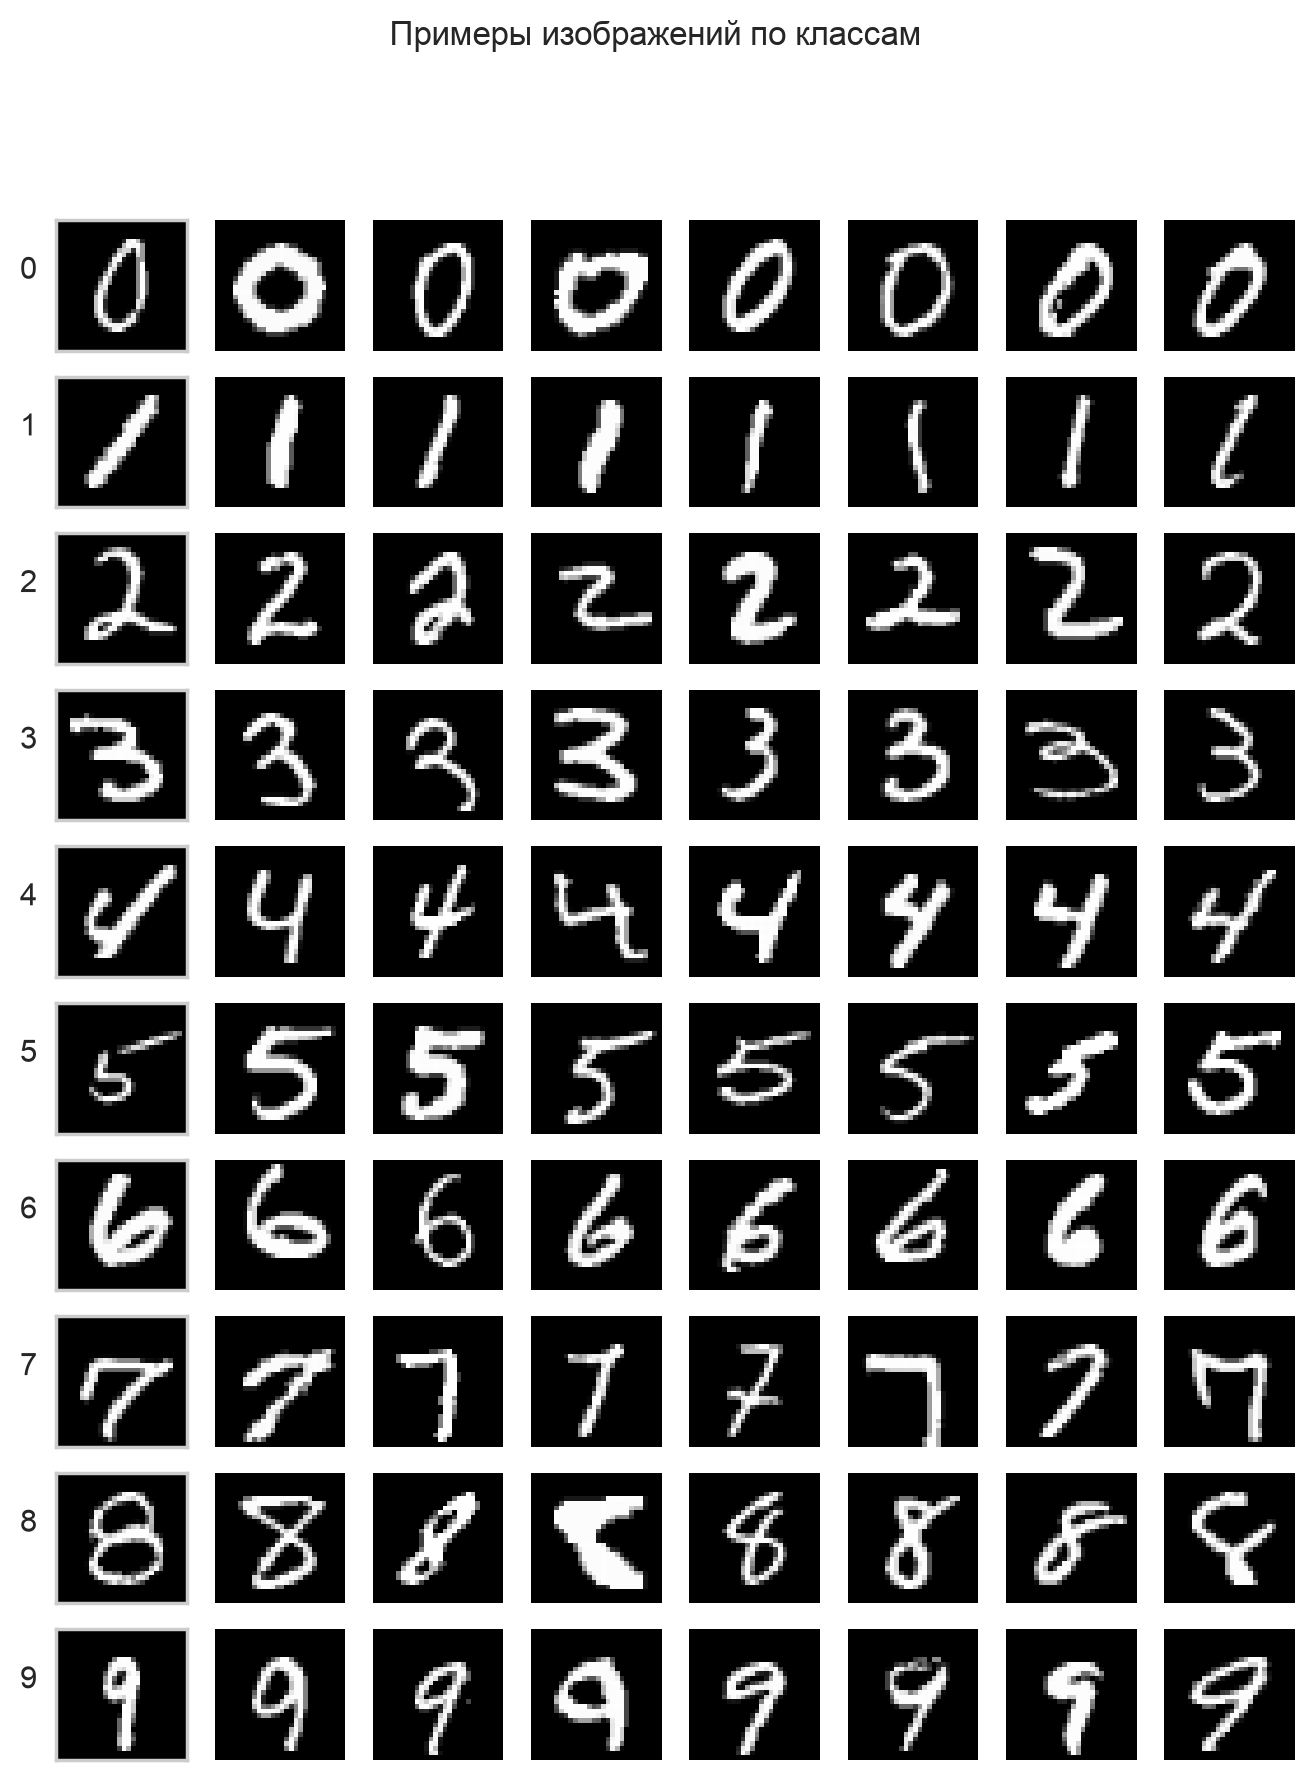

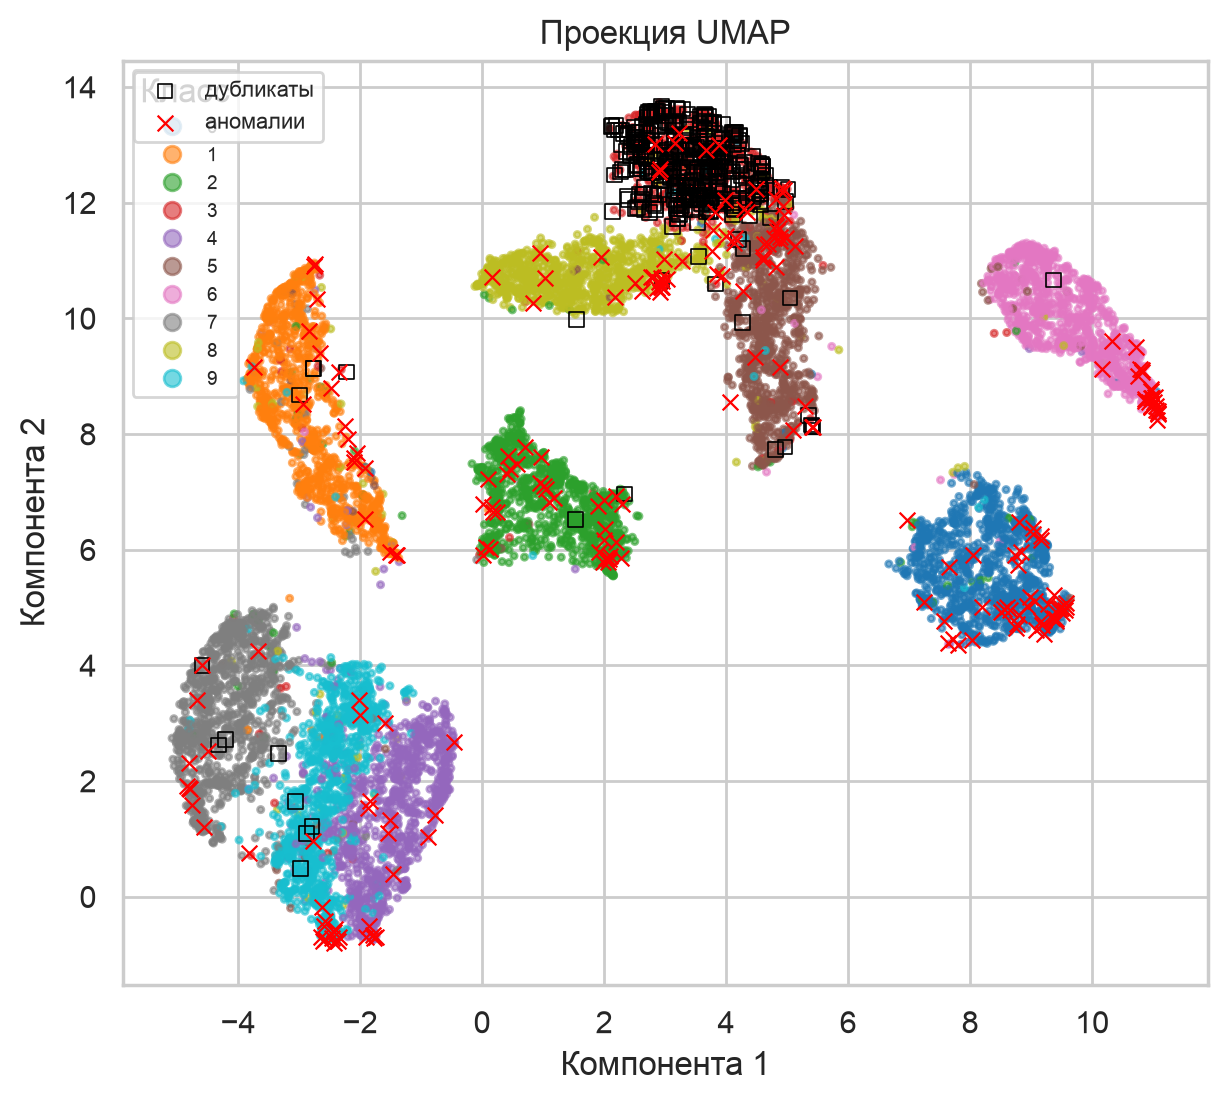

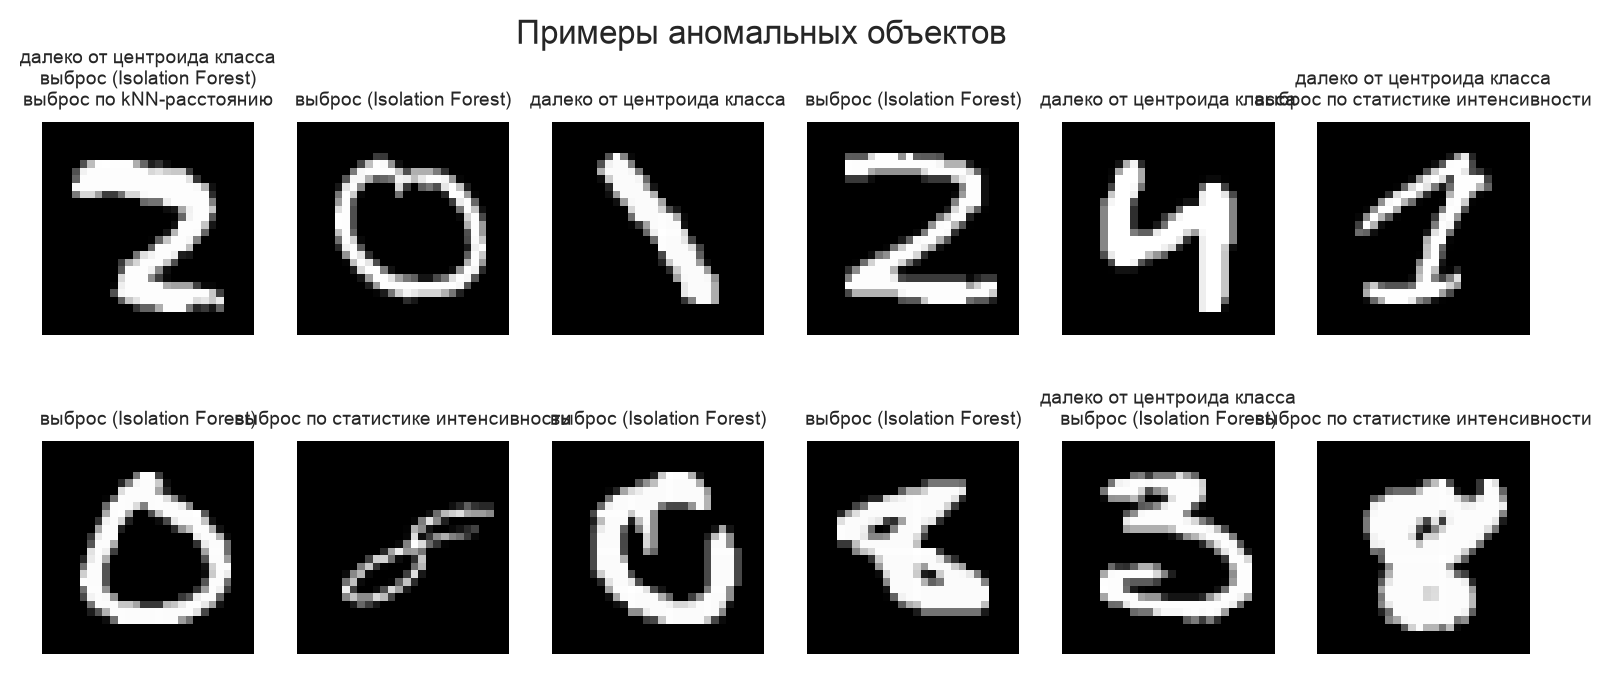

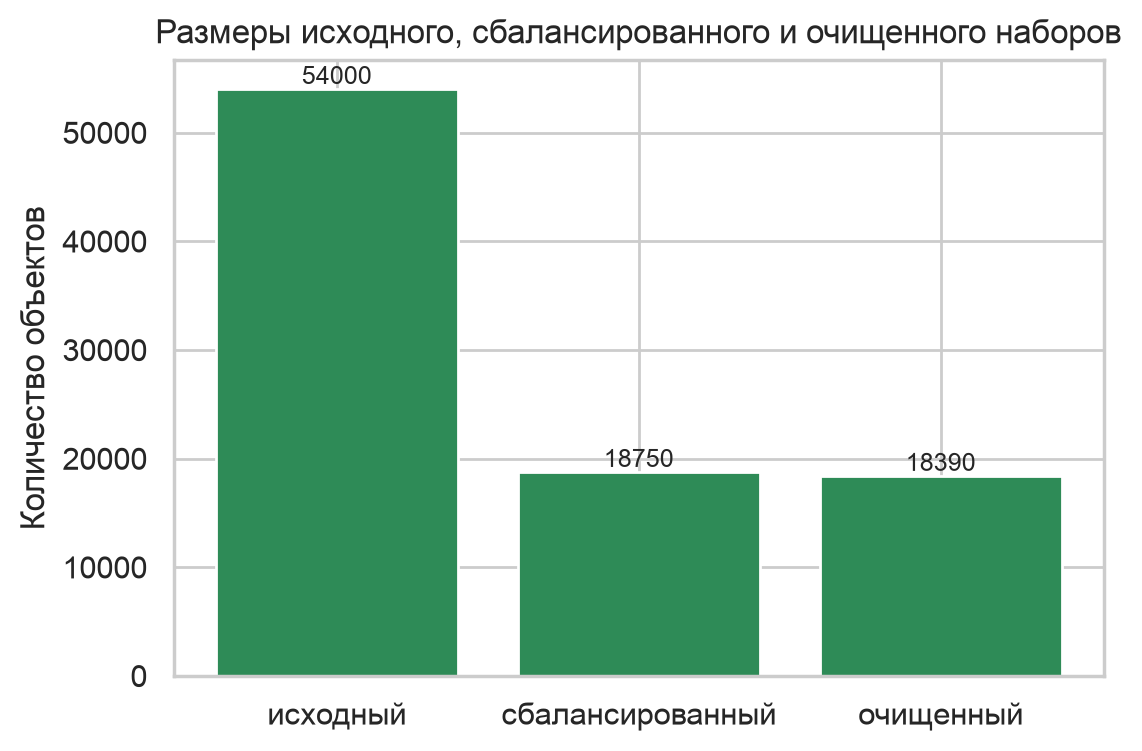

In [4]:
for name in ['part1_class_histogram', 'part1_examples', 'part1_umap',
             'part1_anomalies', 'part1_dataset_sizes']:
    display(Image(str(FIG / f'{name}.png')))

Набор количественно репрезентативен (объёма хватает всем классам), но сильно несбалансирован (класс 3 раздут дубликатами, класс 9 урезан). Аномалии (~2,35 %) сохранены для Части 3.

## Часть 2. Обучение и сравнение моделей

Сводка сетки экспериментов и итоговые метрики трёх моделей.

In [5]:
grid = pd.read_csv(TAB / 'part2_grid.csv')
display(grid.sort_values('val_macro_f1', ascending=False).head(10))
display(pd.read_csv(TAB / 'part2_final_metrics.csv'))
print(json.loads((TAB / 'part2_summary.json').read_text())['best_by_dataset'])

,dataset,activation,dropout,val_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,test_error_rate,mean_conf_correct,mean_conf_incorrect,best_epoch,num_parameters,train_seconds
3,original,tanh,0.0,0.983079,0.9790,0.978846,0.978972,0.0210,0.995418,0.812099,20,235146,56.78
1,original,relu,0.2,0.982654,0.9818,0.981675,0.981770,0.0182,0.994704,0.819829,23,235146,115.34
2,original,relu,0.5,0.982565,0.9780,0.977779,0.977960,0.0220,0.991055,0.756058,23,235146,134.74
8,original,gelu,0.5,0.982307,0.9799,0.979805,0.979855,0.0201,0.992440,0.793149,23,235146,66.23
7,original,gelu,0.2,0.981835,0.9772,0.976946,0.977170,0.0228,0.995036,0.817701,18,235146,53.92
4,original,tanh,0.2,0.981481,0.9770,0.976771,0.976948,0.0230,0.992818,0.795605,20,235146,86.92
6,original,gelu,0.0,0.981432,0.9792,0.979122,0.979169,0.0208,0.995592,0.819161,15,235146,72.46
0,original,relu,0.0,0.980002,0.9789,0.978703,0.978899,0.0211,0.994103,0.818626,13,235146,36.63
5,original,tanh,0.5,0.973930,0.9733,0.973080,0.973244,0.0267,0.990501,0.770415,30,235146,118.15
17,balanced,gelu,0.5,0.971444,0.9747,0.974533,0.974678,0.0253,0.991411,0.820915,29,235146,25.91


,dataset,activation,dropout,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,n_errors,error_rate,mean_confidence_correct,mean_confidence_incorrect
0,original,tanh,0.0,0.9790,0.978846,0.978933,0.978846,0.978972,210.0,0.0210,0.995418,0.812099
1,balanced,gelu,0.5,0.9747,0.974620,0.974545,0.974533,0.974678,253.0,0.0253,0.991411,0.820915
2,cleaned,gelu,0.5,0.9709,0.970750,0.970653,0.970650,0.970879,291.0,0.0291,0.992617,0.796567


{'original': {'activation': 'tanh', 'dropout': 0.0, 'val_macro_f1': 0.9831, 'test_accuracy': 0.979, 'test_macro_f1': 0.9788}, 'balanced': {'activation': 'gelu', 'dropout': 0.5, 'val_macro_f1': 0.9714, 'test_accuracy': 0.9747, 'test_macro_f1': 0.9745}, 'cleaned': {'activation': 'gelu', 'dropout': 0.5, 'val_macro_f1': 0.9693, 'test_accuracy': 0.9709, 'test_macro_f1': 0.9707}}


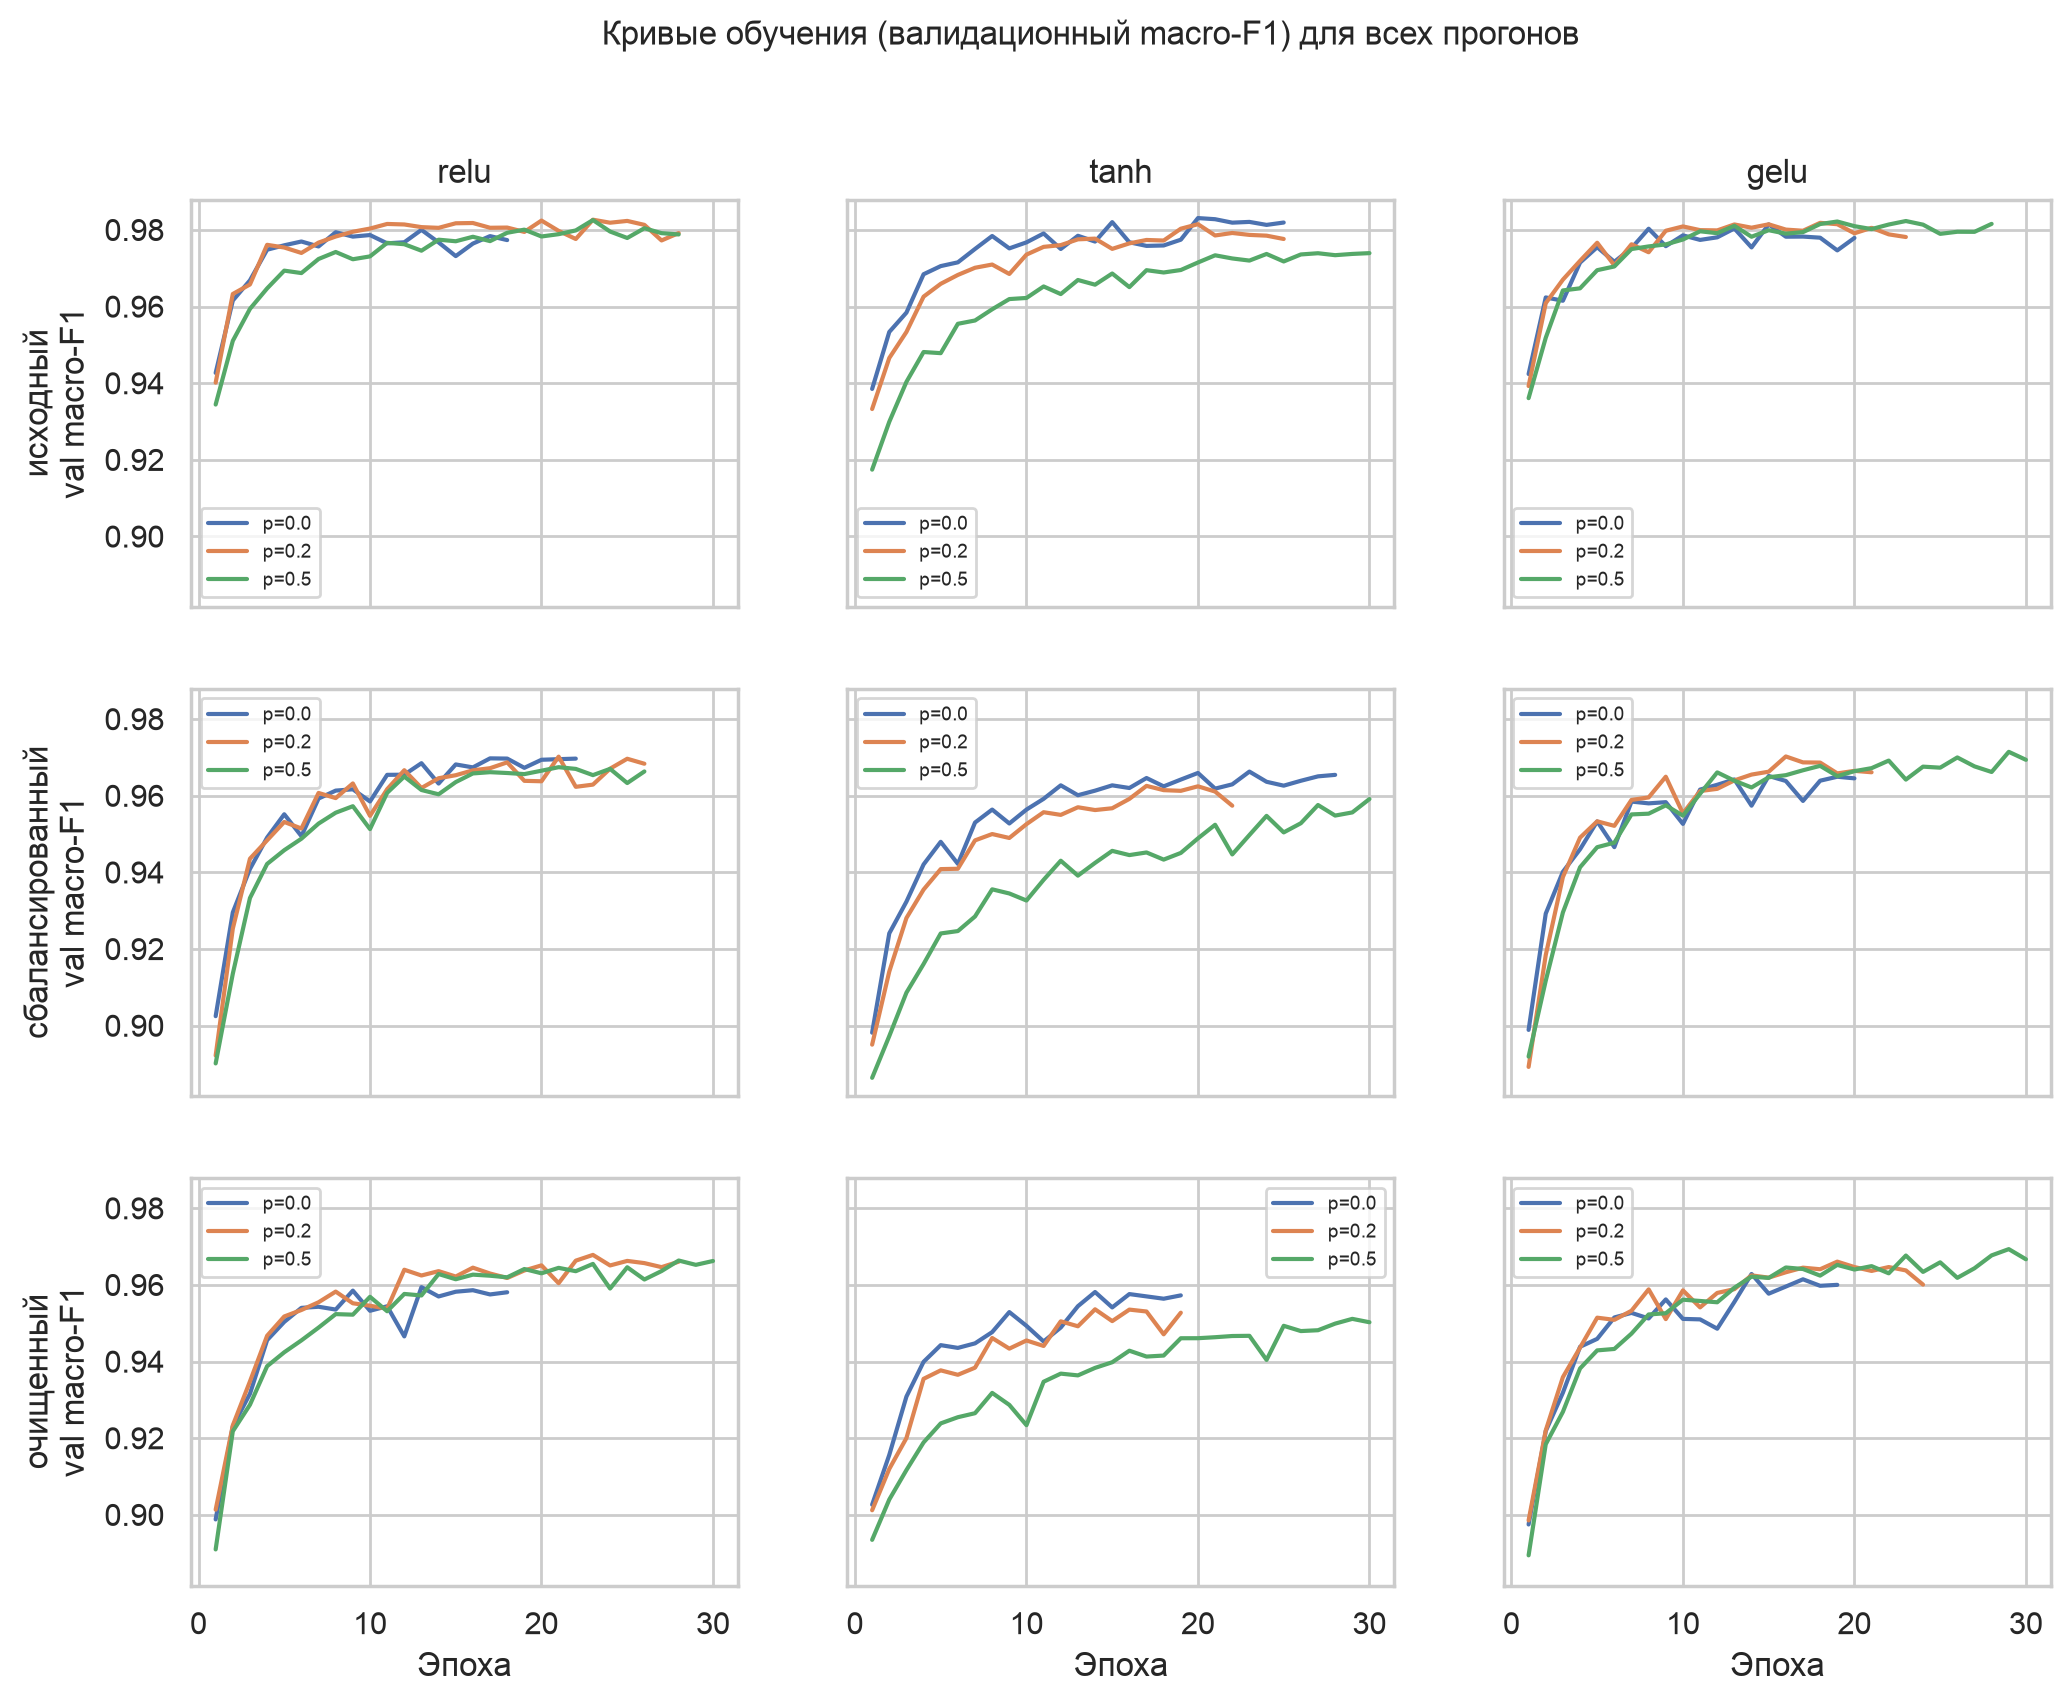

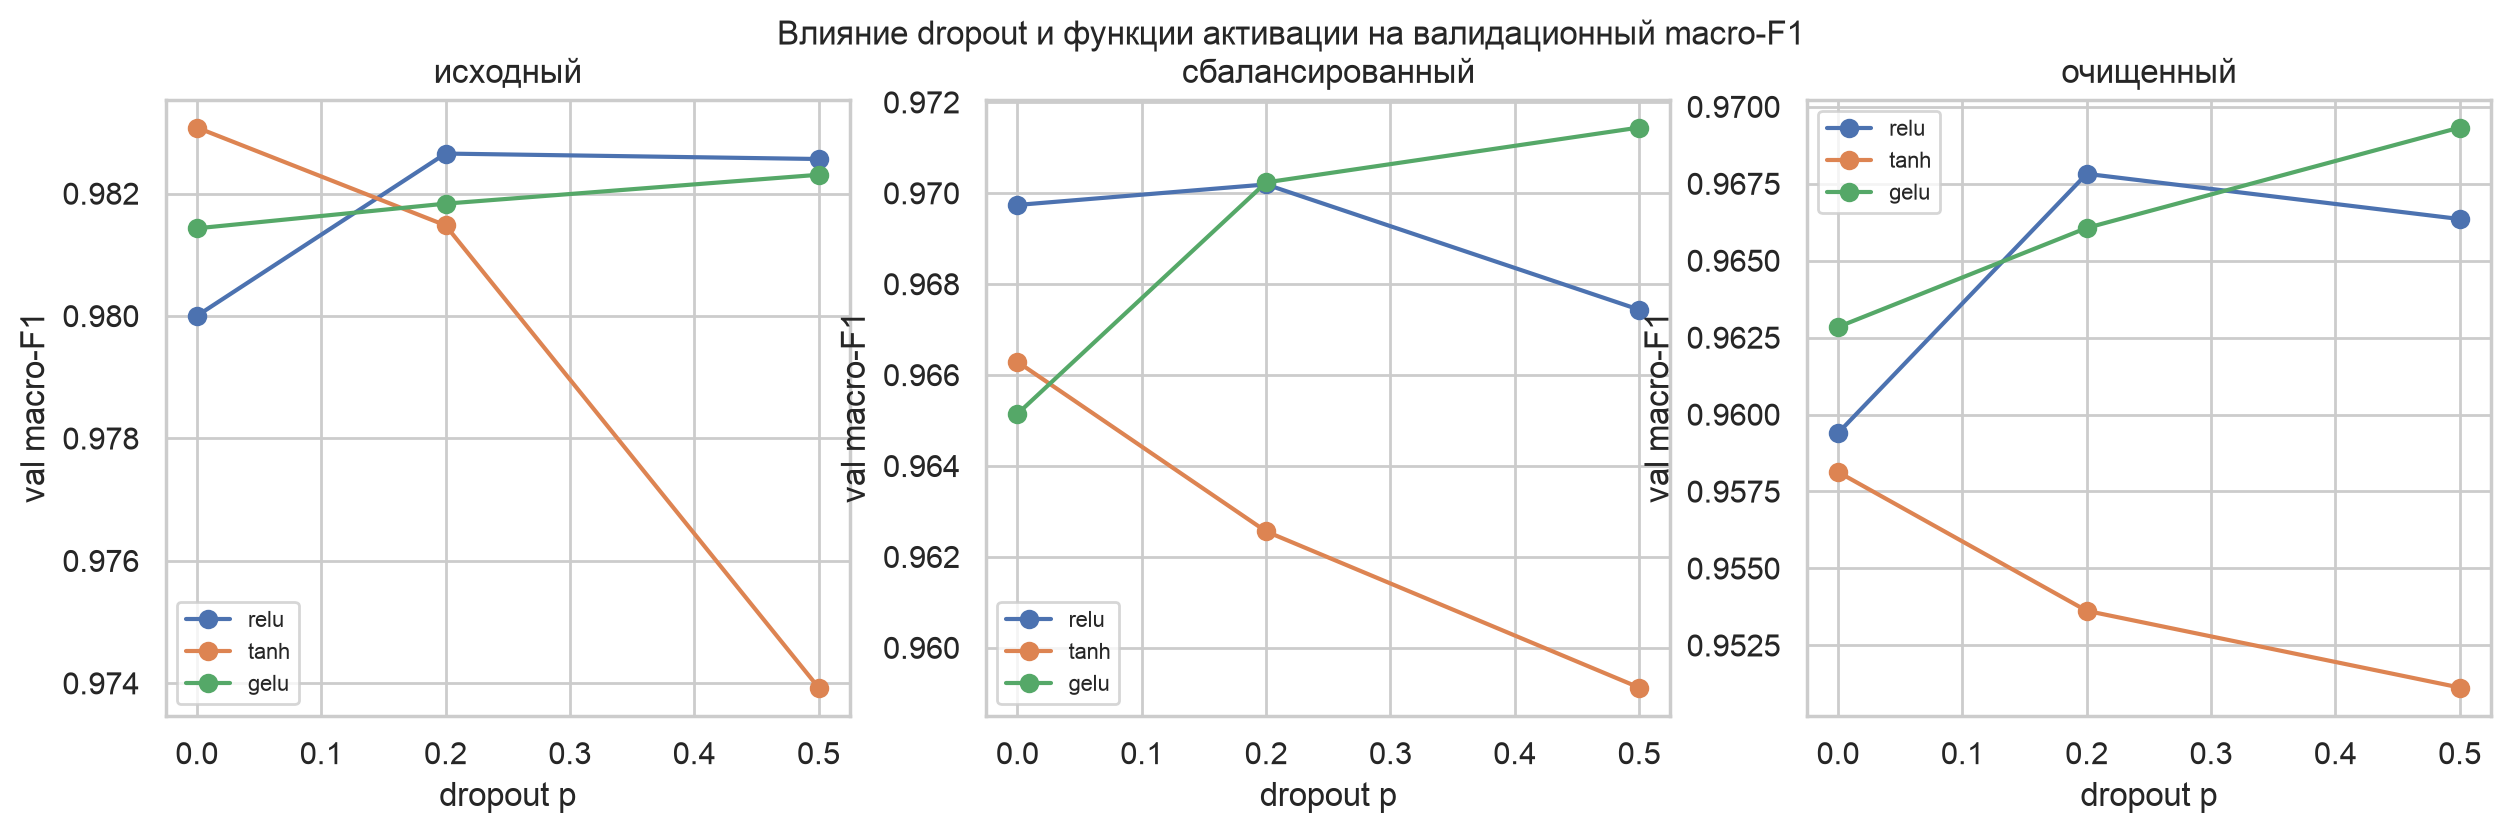

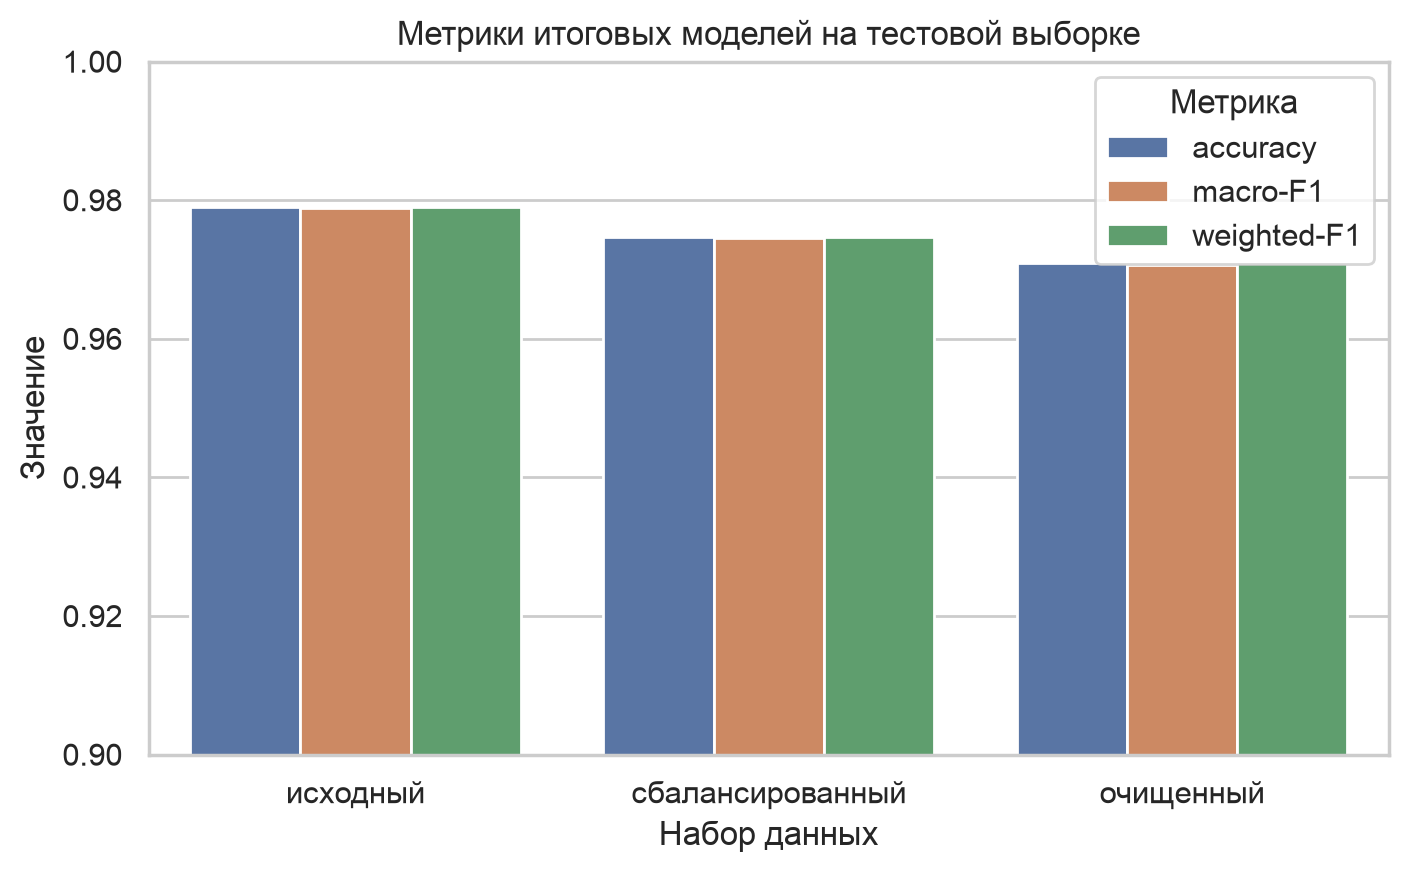

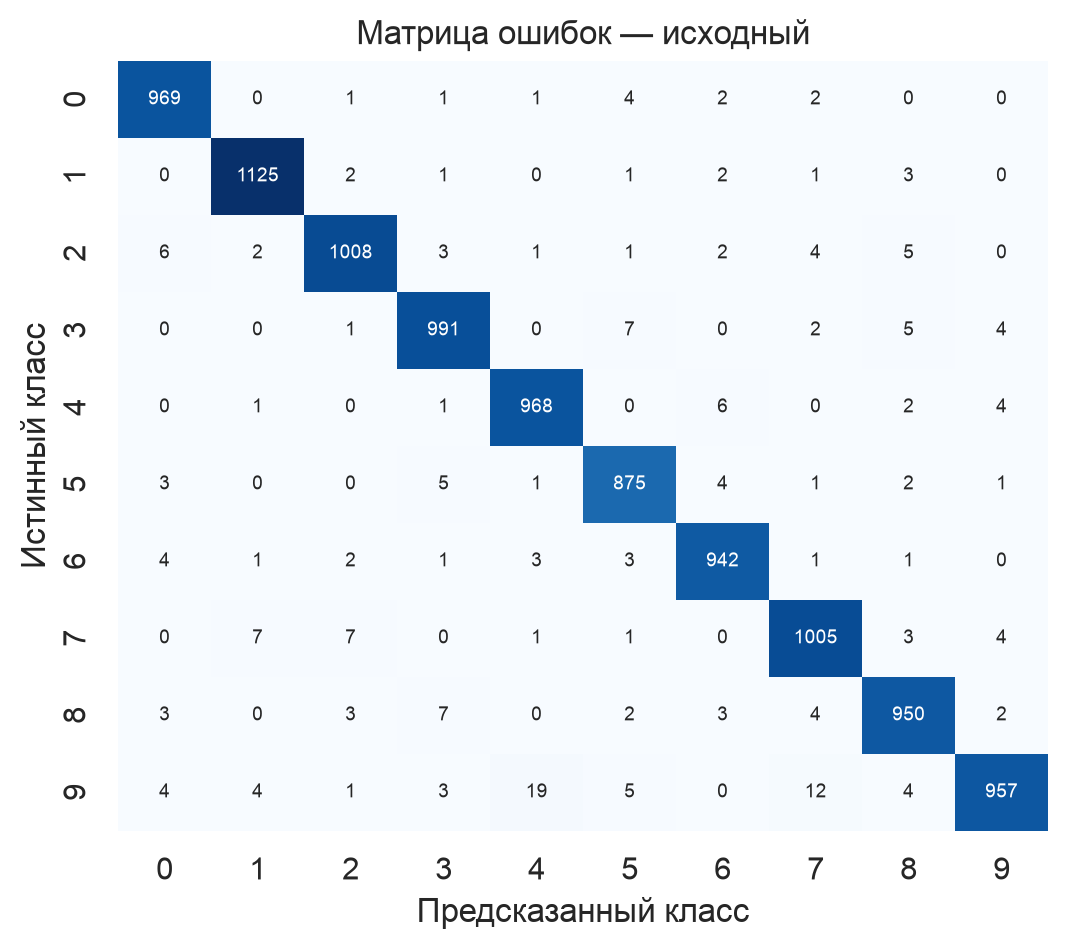

In [6]:
for name in ['part2_grid_curves', 'part2_hyperparams', 'part2_metric_bars',
             'part2_confusion_original']:
    display(Image(str(FIG / f'{name}.png')))

Лучшая модель — на исходном наборе (больше данных перевешивает дисбаланс); на меньших сбалансированном/очищенном наборах оптимален dropout 0,5.

## Часть 3. Оценка и интерпретация

Живой расчёт метрик и одной карты окклюзии на загруженной итоговой модели, затем готовые рисунки/таблицы.

In [7]:
import numpy as np
from mnist_validation.models.torch_mlp import load_torch_model, resolve_device
from mnist_validation.evaluation.metrics import compute_metrics
from mnist_validation.preprocessing import to_float01

device = resolve_device('cpu')
clf = load_torch_model(ROOT / 'artifacts' / 'final' / 'original.pt', device)
metrics = compute_metrics(test.labels, clf.predict_logits(to_float01(test.images).astype('float64')))
print('test accuracy:', round(metrics.accuracy, 4), '| macro-F1:', round(metrics.macro_f1, 4))

test accuracy: 0.979 | macro-F1: 0.9788


In [8]:
from mnist_validation.interpretation.occlusion import occlusion_map

pos = int(np.flatnonzero(test.labels == 3)[0])
image = to_float01(test.images[pos:pos+1]).astype('float64')[0]
res = occlusion_map(clf, image, true_label=3, kernel=3)
print('предсказанный класс:', res.predicted_class, '| базовая вероятность:', round(res.base_prob_pred, 3))
print('форма карты важности:', res.importance_pred.shape)

предсказанный класс: 3 | базовая вероятность: 0.998
форма карты важности: (28, 28)


,dataset,true_class,predicted_class,count
0,original,9,4,19
1,original,9,7,12
2,original,3,5,7
3,original,7,1,7
4,original,7,2,7


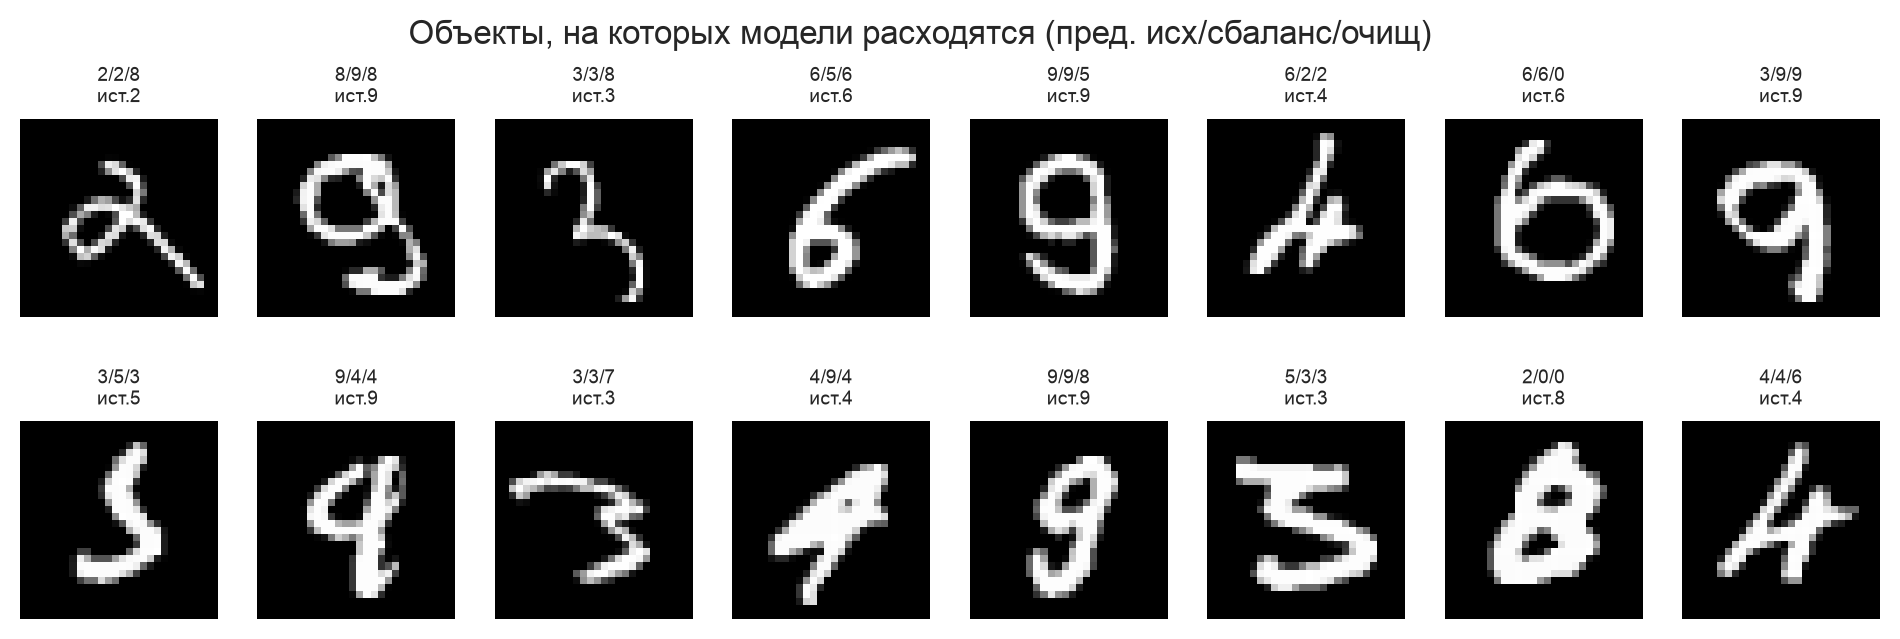

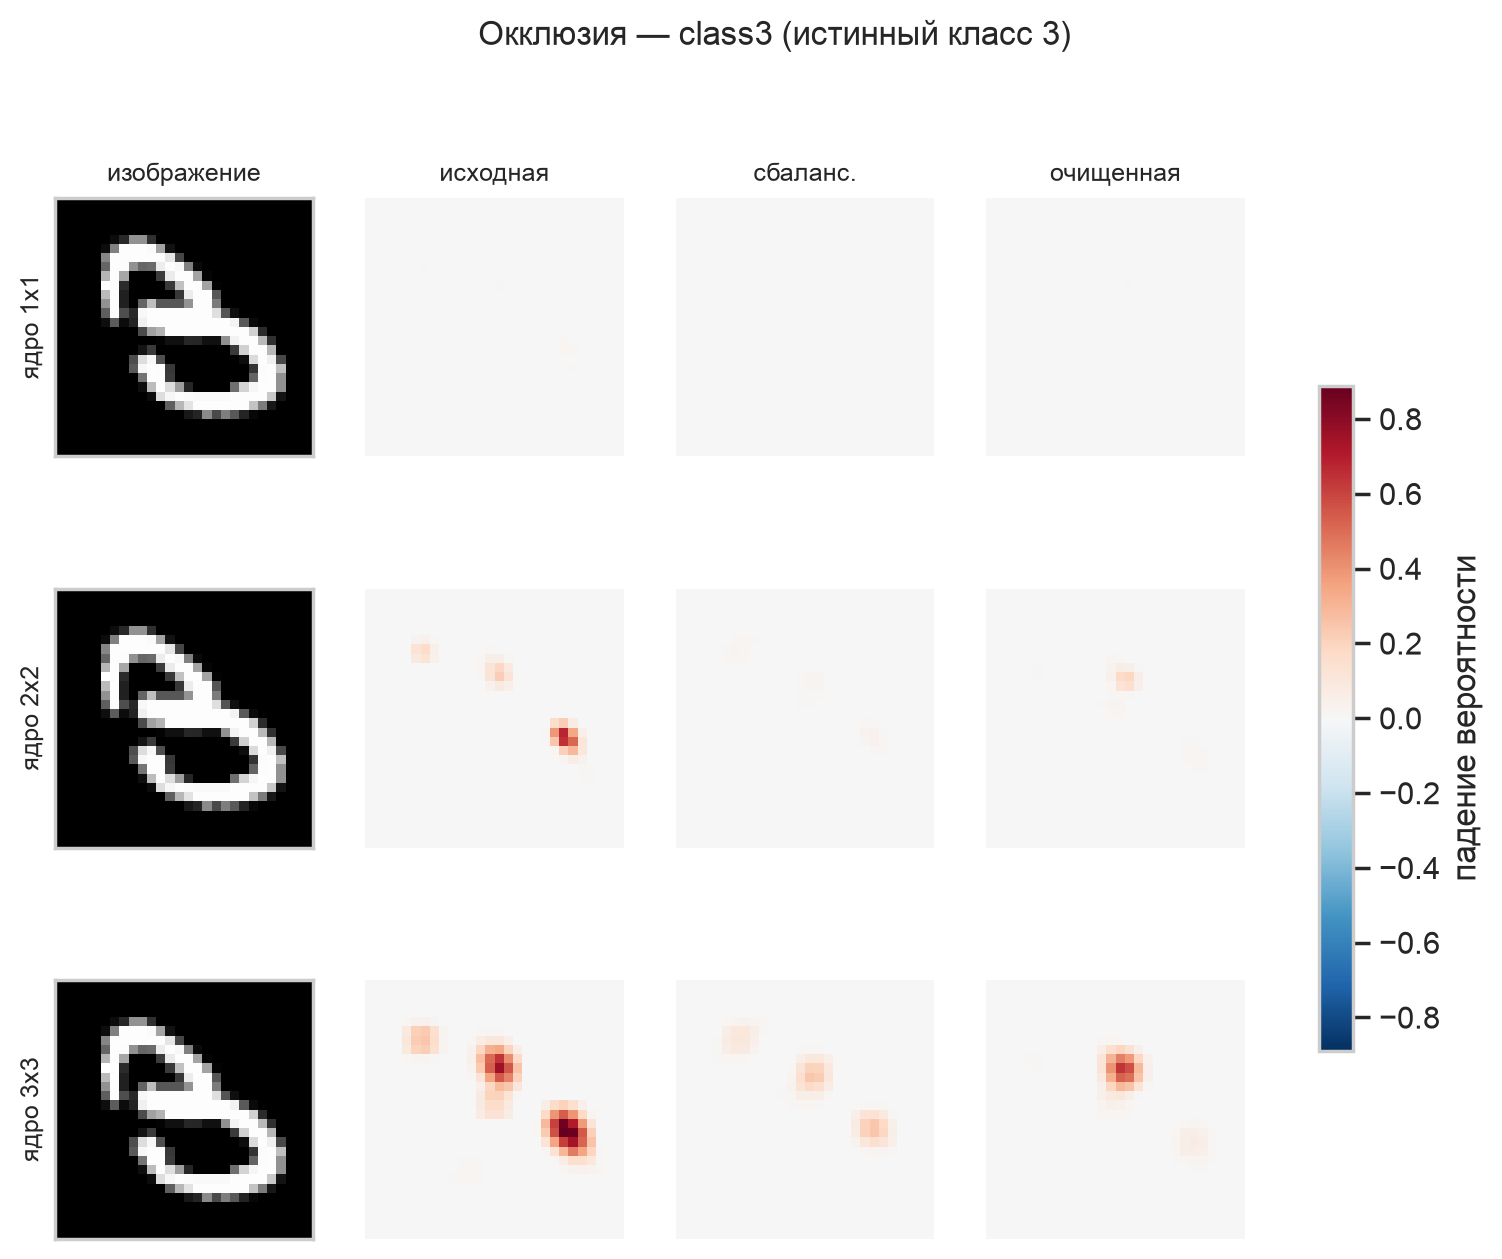

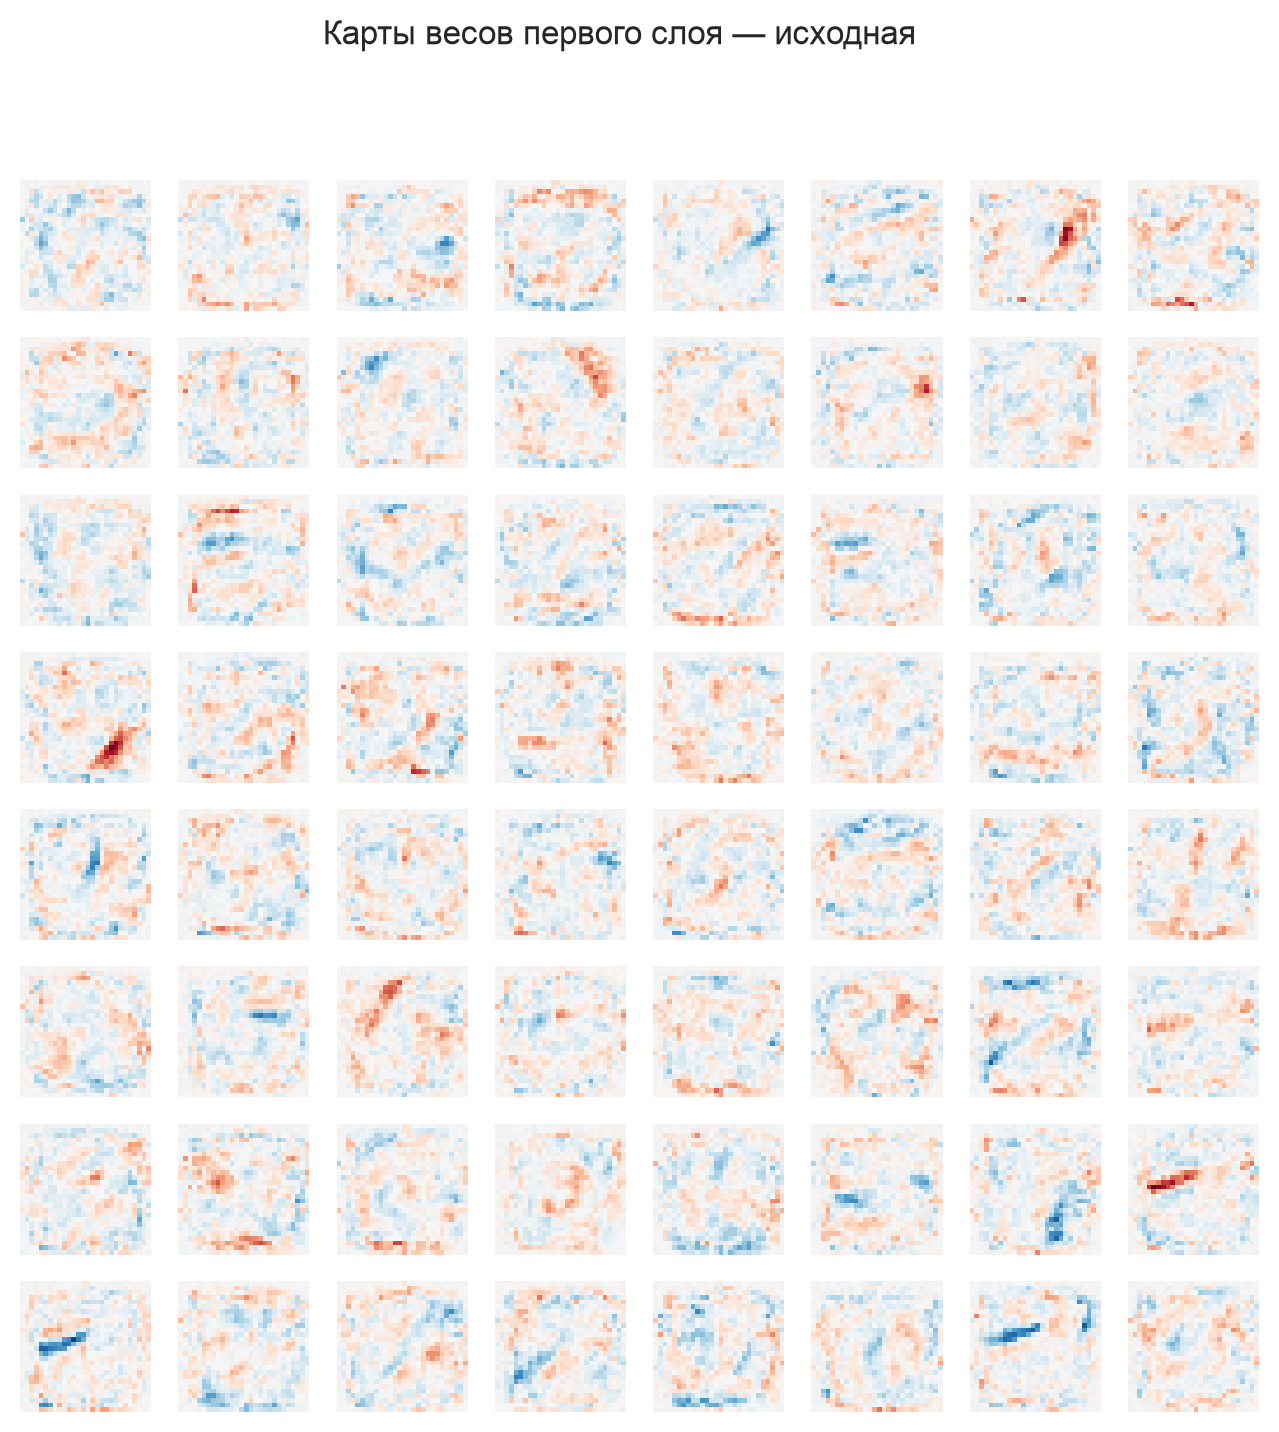

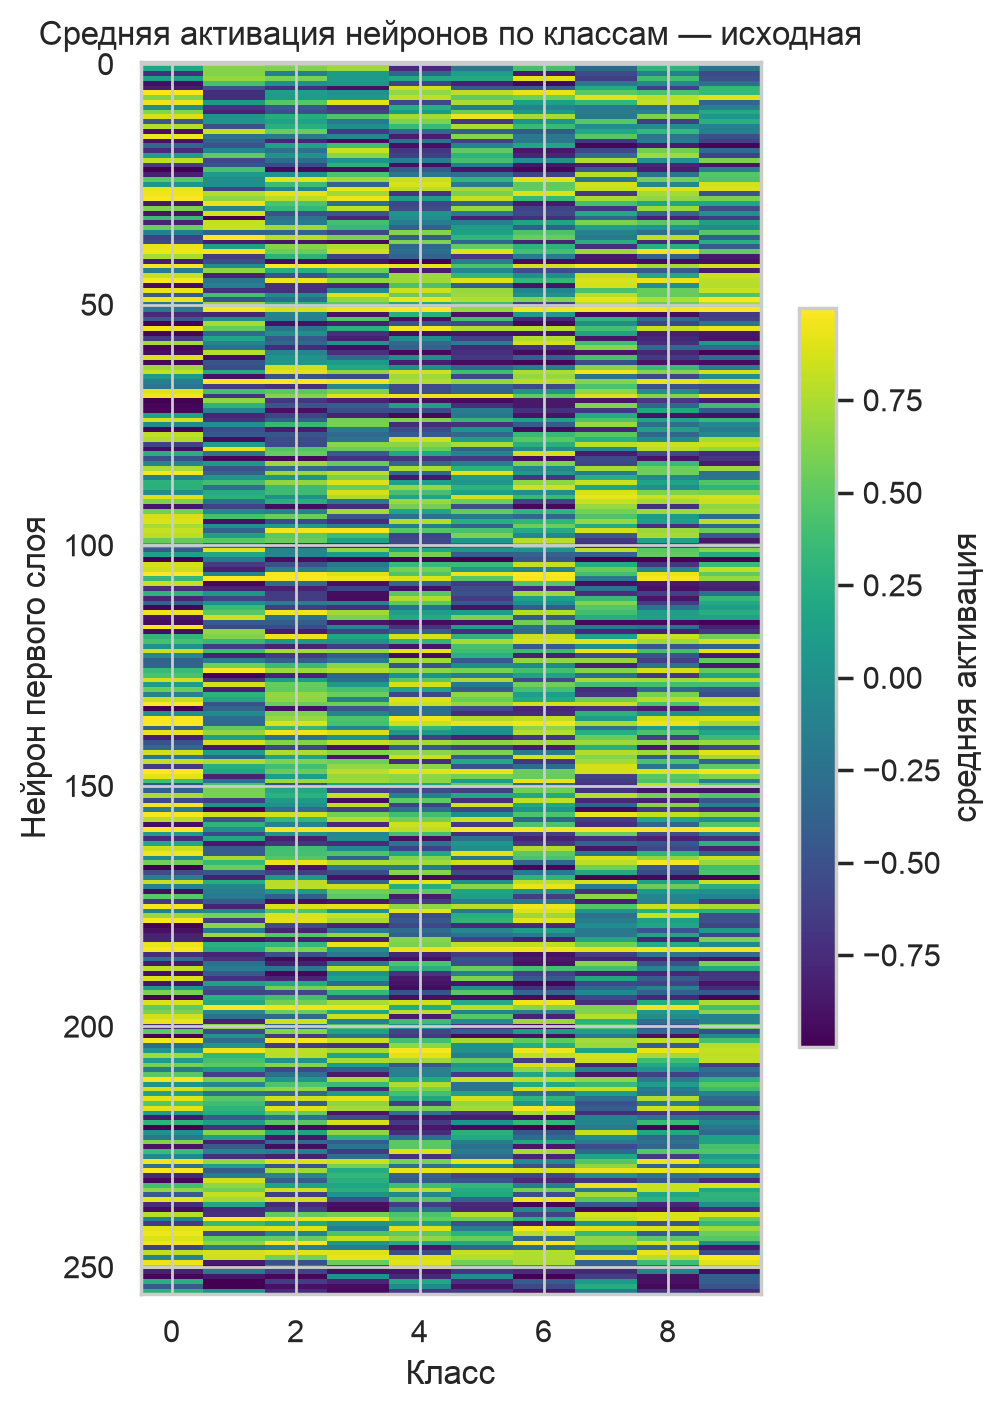

In [9]:
display(pd.read_csv(TAB / 'part3_confused_pairs.csv').head(5))
for name in ['part3_disagreement', 'part3_occlusion_class3', 'part3_weights_original',
             'part3_activation_original']:
    display(Image(str(FIG / f'{name}.png')))

Аномальные объекты в большинстве по-прежнему уверенно и верно классифицируются (в среднем 2,74 из 3 моделей согласны с исходной меткой), поэтому их удаление почти не влияет на метрики.

## Часть 4. Сравнение PyTorch и JAX и градиентные методы

In [10]:
display(pd.read_csv(TAB / 'part4_frameworks.csv'))
display(pd.read_csv(TAB / 'part4_error_overlap.csv'))
display(pd.read_csv(TAB / 'part4_map_correlation.csv'))

,dataset,framework,activation,dropout,test_accuracy,test_macro_f1,macro_f1_mean,macro_f1_std,train_seconds_mean
0,original,PyTorch,tanh,0.0,0.9790,0.978846,0.977262,0.001125,66.201670
1,original,JAX,tanh,0.0,0.9822,0.982059,0.980987,0.000863,87.388759
2,balanced,PyTorch,gelu,0.5,0.9747,0.974533,0.973404,0.000983,33.908963
3,balanced,JAX,gelu,0.5,0.9755,0.975387,0.973884,0.001066,28.140204
4,cleaned,PyTorch,gelu,0.5,0.9709,0.970650,0.970308,0.000905,29.982602
5,cleaned,JAX,gelu,0.5,0.9694,0.969188,0.971129,0.001462,24.033063


,dataset,torch_errors,jax_errors,shared_errors,error_jaccard,prediction_agreement
0,original,210,178,135,0.533597,0.9861
1,balanced,253,245,183,0.580952,0.9852
2,cleaned,291,306,228,0.617886,0.9836


,class,corr_saliency_torch_jax,corr_occlusion_vs_saliency
0,0,0.777012,0.072287
1,3,0.721772,0.205957
2,8,0.682143,0.095155
3,9,0.813205,-0.034004


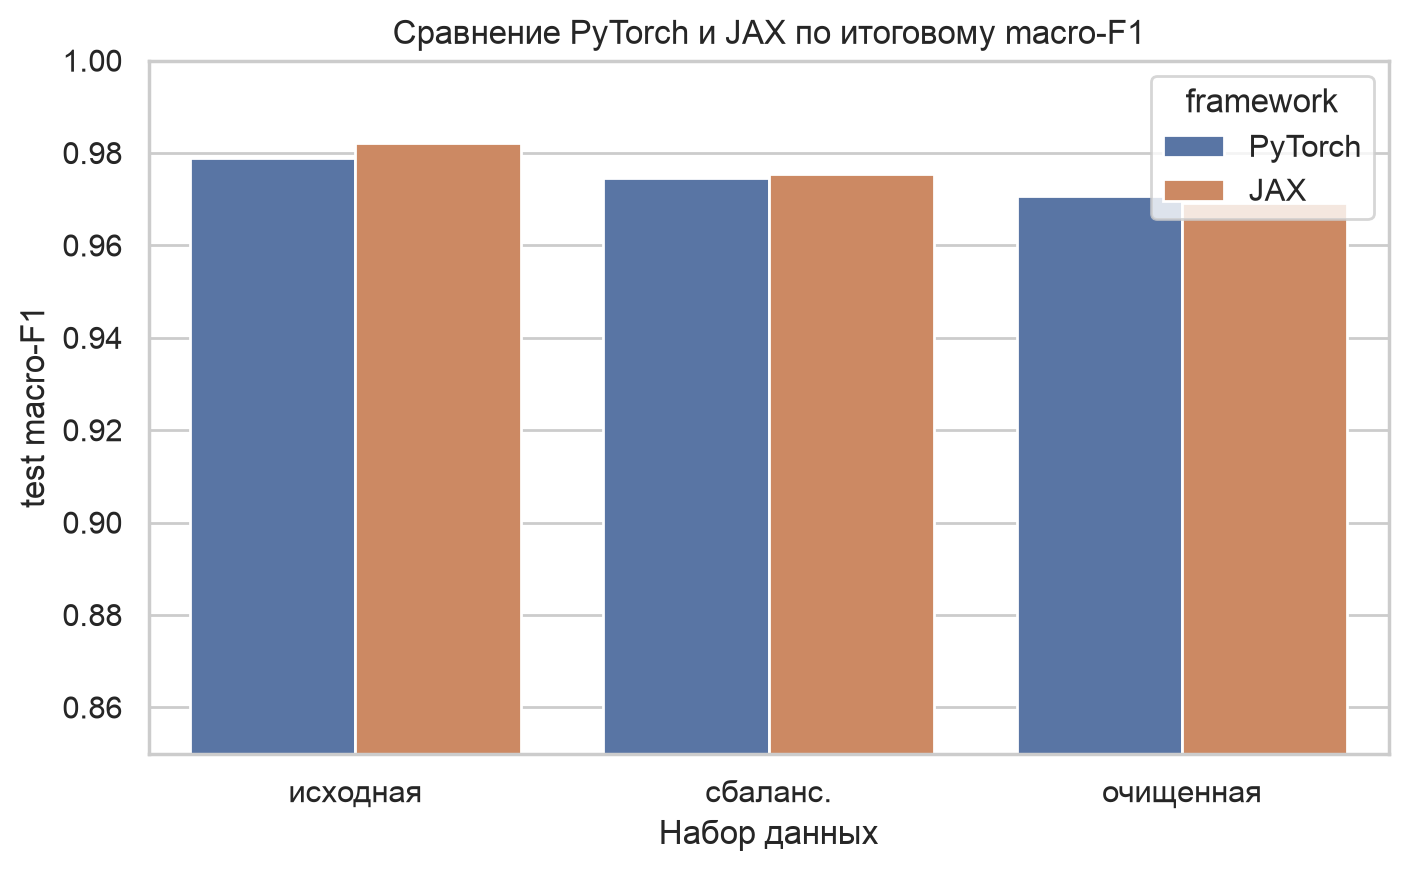

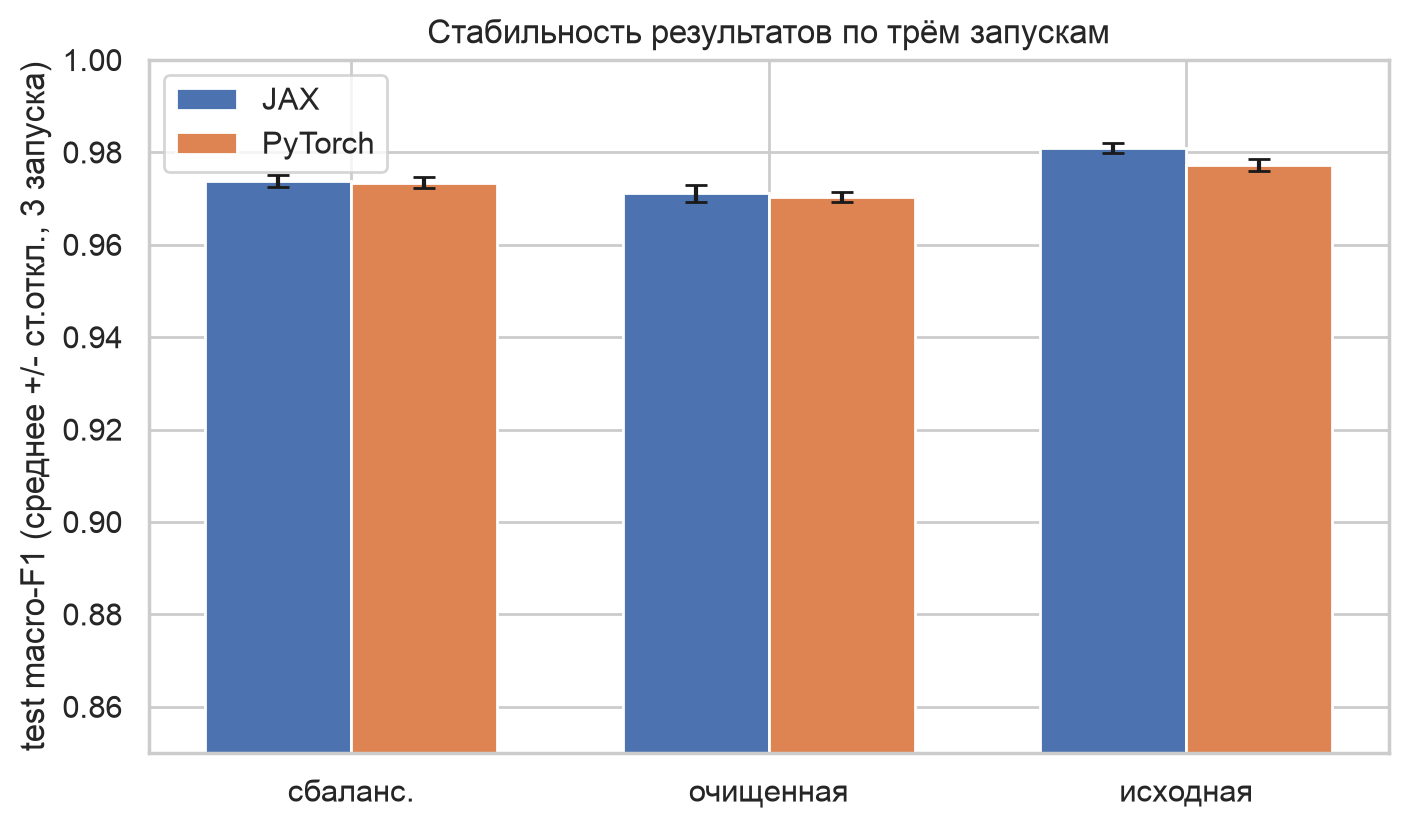

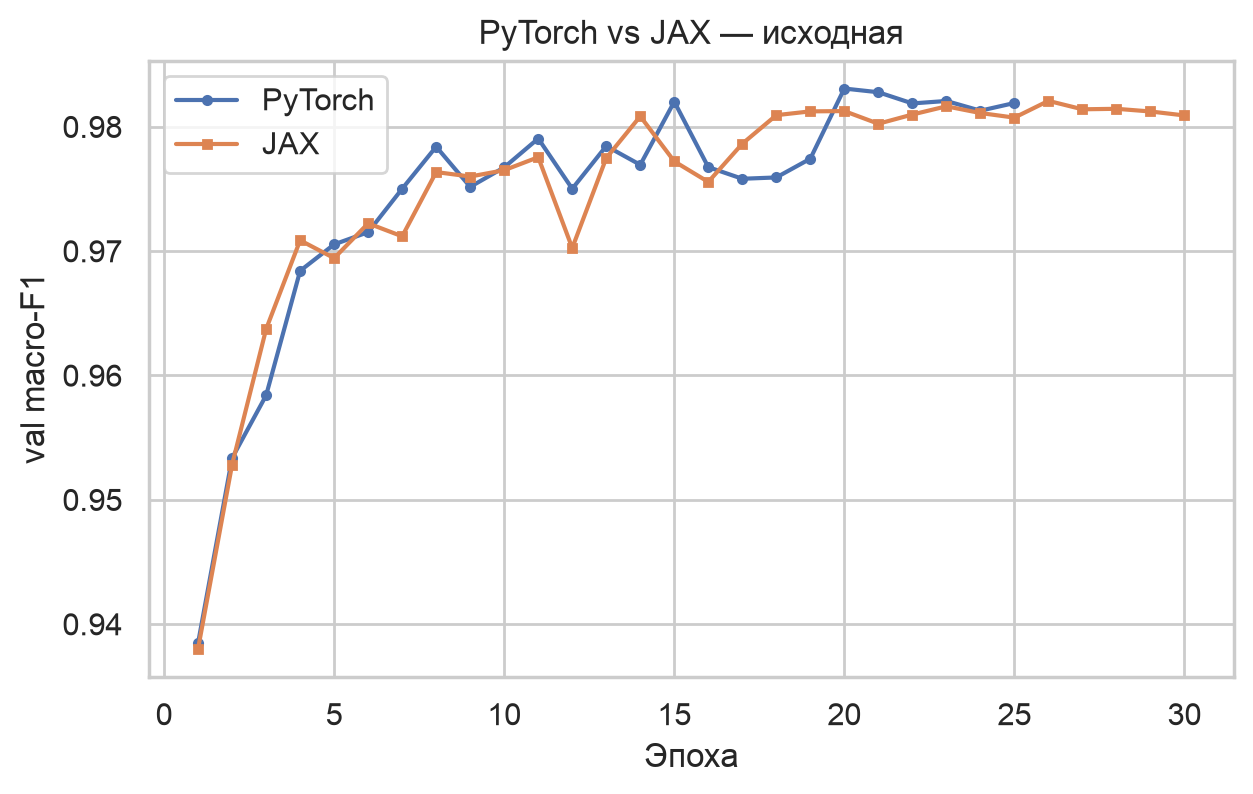

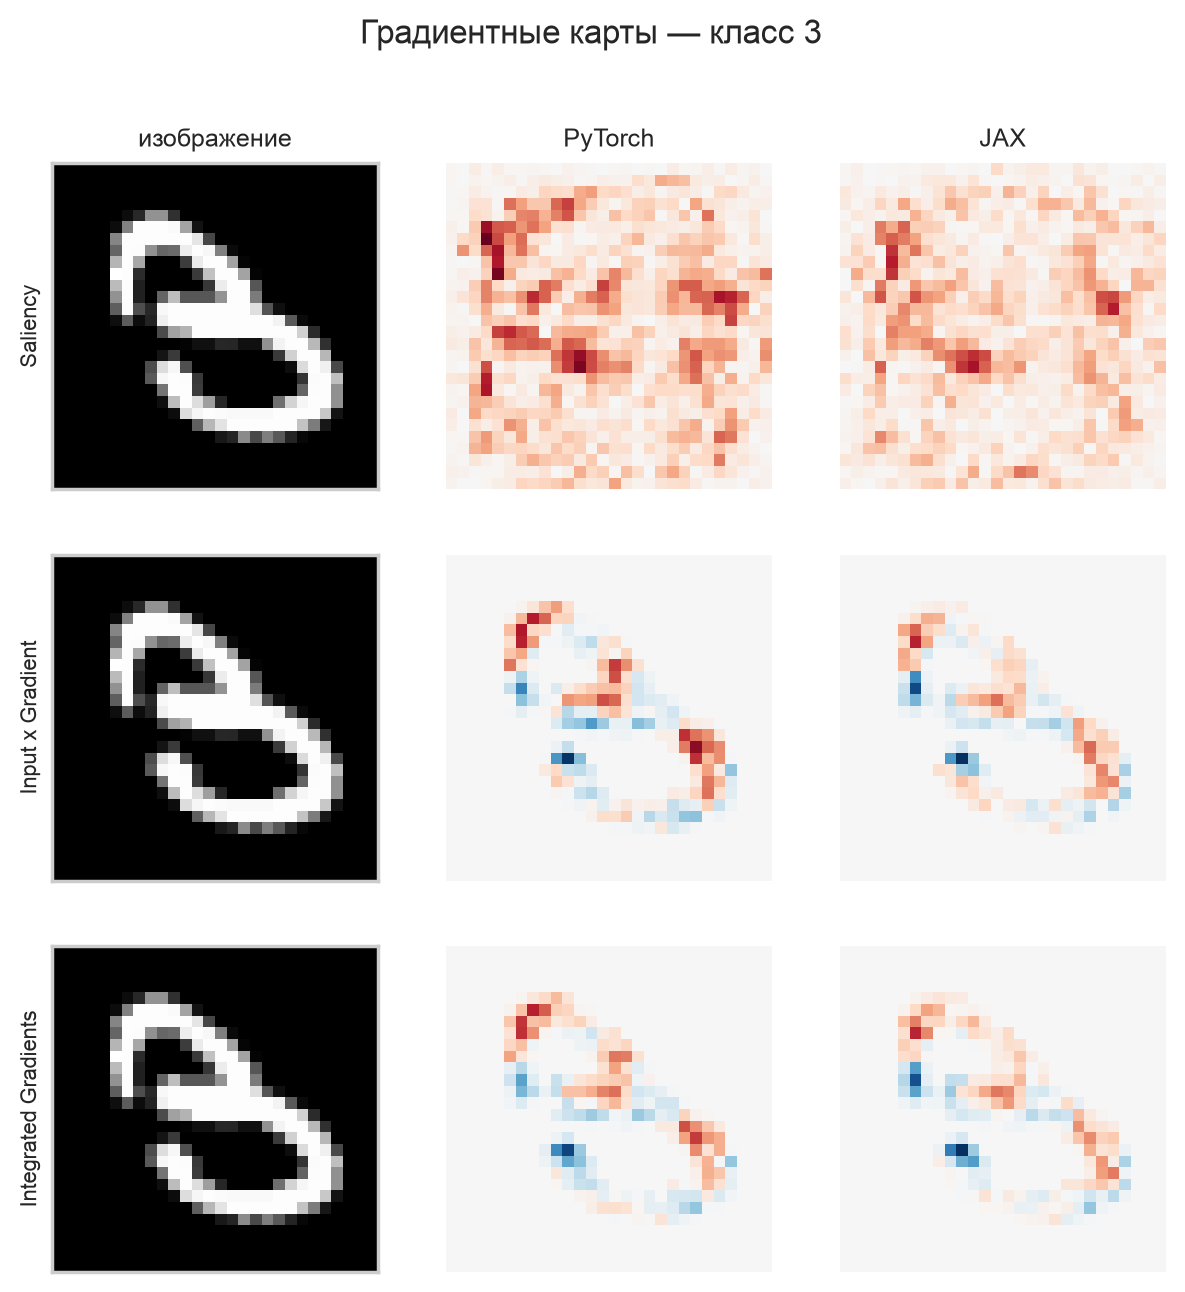

In [11]:
for name in ['part4_framework_bars', 'part4_stability', 'part4_curves_original',
             'part4_gradients_class3']:
    p = FIG / f'{name}.png'
    if p.exists():
        display(Image(str(p)))

PyTorch и JAX при одинаковых условиях дают близкие метрики и сильно пересекающиеся множества ошибок; расхождения объясняются разной инициализацией, реализацией dropout и численной точностью. Градиентные карты (Saliency, Input×Gradient, Integrated Gradients) согласуются между фреймворками и коррелируют с картами окклюзии.

## Выводы

Полные выводы — в `reports/report.md`. Ключевое: набор количественно репрезентативен, но несбалансирован и содержит дубликаты и выбросы; двухслойный перцептрон достигает ~0,97–0,98 macro-F1; интерпретация (окклюзия, карты весов, градиентные методы) показывает, что модель опирается на осмысленные штрихи цифр; PyTorch и JAX сопоставимы.